# TN Salary-vs-Cost-of-Living Pipeline

This notebook has two parts:

**Part I** `JobDataClean.csv` from already-merged `merged_data.csv`, skipping the ONET occupation-category step (for now) using a placeholder category instead, to test everything else first and add real categories back in later.

**Part II**full pipeline adding COUNTY from ZIP, building the HUD cost-of-living threshold, computing proximity, bin into temperature, aggregate, and draw the sanity-check heatmap. **Stop after the heatmap** -- the map and dashboard cells at the very end need a county shapefile we haven't set up yet.

In [19]:
import pandas as pd
import numpy as np
import geopandas as gpd
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

DATA_DIR = 'data'


## Part I: Build JobDataClean.csv from merged_data.csv

Place `merged_data.csv` at `data/merged_data.csv` (next to this notebook) before running this.

In [20]:
jobs = pd.read_csv(f'{DATA_DIR}/merged_data.csv')
print(jobs.columns.tolist())


['Unnamed: 0', 'CITY', 'COMPANY_ID', 'COMPANY_NAME', 'COUNTRY', 'CREATED', 'DELETE_DATE', 'LAST_CHECKED', 'LAST_UPDATED', 'STATE', 'TITLE', 'UNMAPPED_LOCATION', 'URL', 'ZIP', 'CURRENCY', 'DATE_TIME', 'EXTRACTED_VALUE_HIGH', 'EXTRACTED_VALUE_LOW', 'FREQUENCY', 'NORMALIZED_ANNUAL_HIGH', 'NORMALIZED_ANNUAL_HIGH_USD', 'NORMALIZED_ANNUAL_LOW', 'NORMALIZED_ANNUAL_LOW_USD', 'NORMALIZED_CURRENCY', 'NORMALIZED_FREQUENCY']


In [21]:
# PLACEHOLDER: stand-in category since im skipping the ONET merge for now.
# Once you redo that merge later, delete this line -- MAJOR_GROUP will come from ONET instead.
jobs['MAJOR_GROUP'] = 'All Occupations'

jobs.to_csv(f'{DATA_DIR}/JobDataClean.csv', index=False)
print(jobs.columns.tolist())


['Unnamed: 0', 'CITY', 'COMPANY_ID', 'COMPANY_NAME', 'COUNTRY', 'CREATED', 'DELETE_DATE', 'LAST_CHECKED', 'LAST_UPDATED', 'STATE', 'TITLE', 'UNMAPPED_LOCATION', 'URL', 'ZIP', 'CURRENCY', 'DATE_TIME', 'EXTRACTED_VALUE_HIGH', 'EXTRACTED_VALUE_LOW', 'FREQUENCY', 'NORMALIZED_ANNUAL_HIGH', 'NORMALIZED_ANNUAL_HIGH_USD', 'NORMALIZED_ANNUAL_LOW', 'NORMALIZED_ANNUAL_LOW_USD', 'NORMALIZED_CURRENCY', 'NORMALIZED_FREQUENCY', 'MAJOR_GROUP']


## Part B: The pipeline

From here on we reload JobDataClean.csv fresh from disk, so this half of the notebook still works later even after you swap the placeholder category out for real ONET data.

In [22]:
jobs = pd.read_csv(f'{DATA_DIR}/JobDataClean.csv', parse_dates=['DATE_TIME'])

# averaged between low/high for a single salary figure per posting, falling back to whichever exists if one is missing
jobs['SALARY_EST'] = jobs[['NORMALIZED_ANNUAL_LOW_USD', 'NORMALIZED_ANNUAL_HIGH_USD']].mean(axis=1)

jobs.head()


,Unnamed: 0,CITY,COMPANY_ID,COMPANY_NAME,COUNTRY,CREATED,DELETE_DATE,LAST_CHECKED,LAST_UPDATED,STATE,...,EXTRACTED_VALUE_LOW,FREQUENCY,NORMALIZED_ANNUAL_HIGH,NORMALIZED_ANNUAL_HIGH_USD,NORMALIZED_ANNUAL_LOW,NORMALIZED_ANNUAL_LOW_USD,NORMALIZED_CURRENCY,NORMALIZED_FREQUENCY,MAJOR_GROUP,SALARY_EST
0,0,collierville,17354,FedEx Corp,USA,2025-03-05 02:26:00+00:00,2025-03-12 05:58:00.000,2025-03-11 05:26:00.000,NaN,TN,...,16.92,hourly,66768.0,66768.0,35193.6,35193.6,USD,hourly,All Occupations,50980.8
1,1,knoxville,2838,Walmart Inc,USA,2025-03-06 20:30:00+00:00,2025-04-09 20:15:00.000,2025-04-08 19:41:00.000,NaN,TN,...,17.00,hourly,49920.0,49920.0,35360.0,35360.0,USD,hourly,All Occupations,42640.0
2,2,signal mountain,24509,AccentCare Inc,USA,2024-03-10 13:44:00+00:00,2024-04-03 15:01:00.000,2024-04-01 14:54:00.000,NaN,TN,...,15.00,hourly,NaN,NaN,31200.0,31200.0,USD,hourly,All Occupations,31200.0
3,3,NaN,8693,CVS Health Corp,USA,2026-07-13 17:50:00+00:00,2026-07-27 19:00:00.000,2026-07-26 16:08:00.000,NaN,TN,...,100000.00,yearly,231540.0,231540.0,100000.0,100000.0,USD,yearly,All Occupations,165770.0
4,4,memphis,122,DHL Group,USA,2024-10-18 11:58:00+00:00,2024-10-30 17:48:00.000,2024-10-29 12:39:00.000,NaN,TN,...,18.55,hourly,NaN,NaN,38584.0,38584.0,USD,hourly,All Occupations,38584.0


### Add COUNTY from ZIP

Grabbed `data/geo/US.txt`, geonames zip-code lookup file used by CaydenSchalk. If it's not already in this project:
1. Go to https://download.geonames.org/export/zip/US.zip and download it (or copy the file from your original project's `data/geo/` folder if you still have it)
2. Unzip it, find the file named `US.txt`
3. Place it at `data/geo/US.txt`

In [25]:
geo_cols = ['country', 'zip', 'place', 'state', 'state_code', 'county', 'county_code',
            'admin3', 'admin3_code', 'lat', 'lon', 'accuracy']
geo = pd.read_csv(f'{DATA_DIR}/geo/US.txt', sep='\t', header=None, names=geo_cols, dtype={'zip': str})
zip_info = geo.drop_duplicates('zip').set_index('zip')

jobs['ZIP5'] = jobs['ZIP'].astype(str).str.extract(r'^(\d{5})')[0]
jobs.loc[jobs['ZIP5'].map(zip_info['state_code']) != 'TN', 'ZIP5'] = np.nan

city_zip = jobs.dropna(subset=['ZIP5', 'CITY']).groupby('CITY')['ZIP5'].agg(lambda s: s.mode()[0])
jobs['ZIP5'] = jobs['ZIP5'].fillna(jobs['CITY'].map(city_zip))

jobs['COUNTY'] = jobs['ZIP5'].map(zip_info['county'])

print(f"rows with a county assigned: {jobs['COUNTY'].notna().mean():.2%}")
jobs[['CITY', 'ZIP', 'ZIP5', 'COUNTY']].head()


rows with a county assigned: 98.84%


,CITY,ZIP,ZIP5,COUNTY
0,collierville,38017,38017,Shelby
1,knoxville,37902,37902,Knox
2,signal mountain,37377,37377,Hamilton
3,NaN,37201,37201,Davidson
4,memphis,38103,38103,Shelby


### Clean up and add time buckets

In [26]:
jobs = jobs.dropna(subset=['SALARY_EST', 'COUNTY'])

jobs['YEAR'] = jobs['DATE_TIME'].dt.year
jobs['QUARTER'] = jobs['DATE_TIME'].dt.to_period('Q').astype(str)  # e.g. "2025Q1"

# normalized the county names to match the FMR/shapefile spelling later ("Davidson" -> "davidson county")
jobs['COUNTY_KEY'] = jobs['COUNTY'].str.lower().str.strip() + ' county'

jobs[['COUNTY', 'COUNTY_KEY', 'QUARTER', 'MAJOR_GROUP', 'SALARY_EST']].head()


,COUNTY,COUNTY_KEY,QUARTER,MAJOR_GROUP,SALARY_EST
0,Shelby,shelby county,2025Q1,All Occupations,50980.8
1,Knox,knox county,2025Q1,All Occupations,42640.0
2,Hamilton,hamilton county,2024Q1,All Occupations,31200.0
3,Davidson,davidson county,2026Q3,All Occupations,165770.0
4,Shelby,shelby county,2024Q4,All Occupations,38584.0


### Cost-of-living threshold: HUD Fair Market Rent x 30% rule

Files: `data/fmr/FY2024.xlsx`, `FY2025.xlsx`, `FY2026.xlsx`. Confirmed real column names: `stusps` (2-letter state code), `countyname` (e.g. "Davidson County"), `fmr_2` (2-bedroom FMR).

In [27]:
fmr_frames = []
for year in (2024, 2025, 2026):
    xl = pd.ExcelFile(f'{DATA_DIR}/fmr/FY{year}.xlsx')
    raw = xl.parse(xl.sheet_names[0])
    raw = raw[raw['stusps'] == 'TN']

    fmr_frames.append(pd.DataFrame({
        'COUNTY_KEY': raw['countyname'].str.lower().str.strip(),
        'YEAR': year,
        'FMR_2BR': raw['fmr_2'],
    }))

fmr = pd.concat(fmr_frames, ignore_index=True)

# 30%-of-income affordability rule: annual housing cost should be <=30% of income
fmr['THRESHOLD_INCOME'] = 12 * fmr['FMR_2BR'] / 0.30

fmr.head()


,COUNTY_KEY,YEAR,FMR_2BR,THRESHOLD_INCOME
0,anderson county,2024,1221,48840.0
1,bedford county,2024,1017,40680.0
2,benton county,2024,861,34440.0
3,bledsoe county,2024,861,34440.0
4,blount county,2024,1221,48840.0


### Join threshold to postings, compute proximity, bin into temperature

In [28]:
jobs = jobs.merge(fmr[['COUNTY_KEY', 'YEAR', 'THRESHOLD_INCOME']], on=['COUNTY_KEY', 'YEAR'], how='left')

jobs['PROXIMITY'] = jobs['SALARY_EST'] / jobs['THRESHOLD_INCOME']

bins = [0, 0.7, 0.9, 1.0, 1.1, 1.3, np.inf]
labels = ['Freezing', 'Cold', 'Cool', 'Lukewarm', 'Warm', 'Hot']
jobs['TEMP'] = pd.cut(jobs['PROXIMITY'], bins=bins, labels=labels)

print(f"rows with a matched threshold: {jobs['THRESHOLD_INCOME'].notna().mean():.2%}")
jobs[['COUNTY', 'QUARTER', 'MAJOR_GROUP', 'SALARY_EST', 'THRESHOLD_INCOME', 'PROXIMITY', 'TEMP']].head(10)


rows with a matched threshold: 100.00%


,COUNTY,QUARTER,MAJOR_GROUP,SALARY_EST,THRESHOLD_INCOME,PROXIMITY,TEMP
0,Shelby,2025Q1,All Occupations,50980.8,54200.0,0.940605,Cool
1,Knox,2025Q1,All Occupations,42640.0,61920.0,0.688630,Freezing
2,Hamilton,2024Q1,All Occupations,31200.0,49280.0,0.633117,Freezing
3,Davidson,2026Q3,All Occupations,165770.0,69200.0,2.395520,Hot
4,Shelby,2024Q4,All Occupations,38584.0,51920.0,0.743143,Cold
5,Shelby,2024Q2,All Occupations,32240.0,51920.0,0.620955,Freezing
6,Shelby,2024Q2,All Occupations,31200.0,51920.0,0.600924,Freezing
7,Davidson,2024Q4,All Occupations,40000.0,64760.0,0.617665,Freezing
8,Sullivan,2025Q4,All Occupations,24960.0,41720.0,0.598274,Freezing
9,Davidson,2024Q4,All Occupations,39936.0,64760.0,0.616677,Freezing


### Aggregate: median proximity per county x occupation group x quarter
(median instead of mean -- salary data has outliers/typos, median is more robust. Right now MAJOR_GROUP is just the placeholder "All Occupations" for everyone, so this will collapse to one row per county per quarter until you add real ONET categories back in.)

In [29]:
agg = (jobs.groupby(['QUARTER', 'MAJOR_GROUP', 'COUNTY', 'COUNTY_KEY'])['PROXIMITY']
       .median()
       .reset_index())
agg.head()


,QUARTER,MAJOR_GROUP,COUNTY,COUNTY_KEY,PROXIMITY
0,2024Q1,All Occupations,Anderson,anderson county,0.851761
1,2024Q1,All Occupations,Bedford,bedford county,1.305113
2,2024Q1,All Occupations,Benton,benton county,0.905923
3,2024Q1,All Occupations,Bledsoe,bledsoe county,0.785134
4,2024Q1,All Occupations,Blount,blount county,0.730811


### Sanity-check heatmap (matrix view, one quarter at a time)

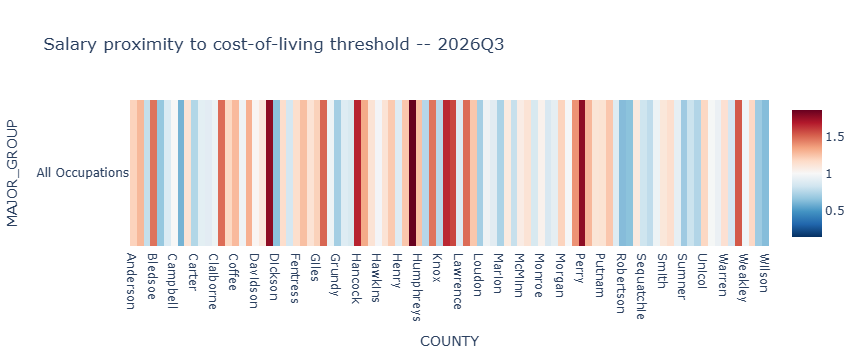

In [30]:
one_quarter = agg[agg['QUARTER'] == agg['QUARTER'].max()]
matrix = one_quarter.pivot(index='MAJOR_GROUP', columns='COUNTY', values='PROXIMITY')

fig_heatmap = px.imshow(
    matrix,
    color_continuous_scale='RdBu_r',   # blue = cold/under threshold, red = hot/over threshold
    color_continuous_midpoint=1.0,
    aspect='auto',
    title=f"Salary proximity to cost-of-living threshold -- {one_quarter['QUARTER'].iloc[0]}"
)
fig_heatmap.show()
